# **EDA Notebook**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
# <Student to fill this section>
group_name = "Group 20"
student_name = "Ratnadeep Patra"
student_id = "26294153"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# <Student to fill this section>

### 0.b Import Packages

In [7]:
# <Student to fill this section>
import pandas as pd
import altair as alt

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "product.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [9]:
pd.set_option('display.max_columns', None) # Forcing pandas to display all columns
pd.set_option('display.max_rows', None) # Forcing pandas to display all rows

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,886,504,3615d396-f30f-4805-b326-de5b780a5507,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,886.0,NaN,NaN,NaN,0.506772,0.500237,0.0,0.0,1.0,1.0,1.0
is_sellable,886.0,NaN,NaN,NaN,0.598194,0.49054,0.0,0.0,1.0,1.0,1.0
safety_stock_level,886.0,NaN,NaN,NaN,530.893905,366.124705,4.0,100.0,500.0,1000.0,1000.0
reorder_point,886.0,NaN,NaN,NaN,398.170429,274.593529,3.0,75.0,375.0,750.0,750.0
days_to_manufacture,886.0,NaN,NaN,NaN,1.128668,1.475729,0.0,0.0,1.0,1.0,4.0
product_subcategory_id,530,37,5fb7ef8d-7610-4230-ae2a-09846fd56ada,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,530.0,NaN,NaN,NaN,37.45283,34.339936,1.0,10.0,26.0,50.0,128.0
name,637,405,"Road-650 Red, 44",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,782,462,SL-0931,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886 entries, 0 to 885
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                886 non-null    object 
 1   is_manufactured           886 non-null    float64
 2   is_sellable               886 non-null    float64
 3   safety_stock_level        886 non-null    float64
 4   reorder_point             886 non-null    float64
 5   days_to_manufacture       886 non-null    float64
 6   product_subcategory_id    530 non-null    object 
 7   product_model_id          530 non-null    float64
 8   name                      637 non-null    object 
 9   product_number            782 non-null    object 
 10  color                     461 non-null    object 
 11  standard_cost             754 non-null    float64
 12  list_price                886 non-null    float64
 13  size                      378 non-null    object 
 14  size_unit_

In [12]:
df.sample(10)

,product_id,is_manufactured,is_sellable,safety_stock_level,reorder_point,days_to_manufacture,product_subcategory_id,product_model_id,name,product_number,color,standard_cost,list_price,size,size_unit_measure_code,weight_unit_measure_code,weight,product_line,class,style,sell_start_date,sell_end_date,discontinued_date
68,446f0960-eabe-457b-bad4-da61ad408fa3,0.0,0.0,1000.0,750.0,0.0,NaN,NaN,NaN,HN-9161,NaN,0.0000,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-30 00:00:00,NaN,NaN
385,4dce003d-ce37-4a4c-9873-eb21430dda23,0.0,0.0,1000.0,750.0,0.0,NaN,NaN,Pinch Bolt,PB-6109,NaN,0.0000,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-30 00:00:00,NaN,NaN
815,27ad5f38-9de0-48ec-8831-bc52864576a3,0.0,0.0,1000.0,750.0,0.0,NaN,NaN,Metal Sheet 3,NaN,NaN,0.0000,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-30 00:00:00,NaN,NaN
424,efed477a-f27f-47ff-b968-9e8d6206bc89,0.0,0.0,800.0,600.0,0.0,NaN,NaN,HL Mountain Rim,RM-M823,NaN,0.0000,0.00,NaN,NaN,8c4f020f-f9c1-492b-8395-1372b7bda7a7,400.00,NaN,NaN,NaN,2008-04-30 00:00:00,NaN,NaN
767,8738ad03-eb07-4a98-9cbb-c99d5f56b317,1.0,1.0,500.0,375.0,1.0,8a2afb4f-58f5-4238-81ee-cea17d307893,100.0,ML Crankset,CS-6583,Black,NaN,256.49,NaN,NaN,8c4f020f-f9c1-492b-8395-1372b7bda7a7,635.00,NaN,M,NaN,2013-05-30 00:00:00,NaN,NaN
512,80532d65-66fe-463c-be59-91eb621386a3,0.0,0.0,1000.0,750.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0000,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-30 00:00:00,NaN,NaN
691,fa3b3c40-ecaf-45e9-a084-1c717ee305a6,1.0,1.0,100.0,75.0,4.0,5332b46f-2ec0-453b-8237-c78051d4c7bf,23.0,NaN,BK-M18S-48,Silver,308.2179,564.99,48,e2e52698-ce31-4fb2-866f-bcffbdfd3147,c4797df8-be0b-4d3a-a6c4-0f1765f0a822,28.42,M,L,U,2013-05-30 00:00:00,NaN,NaN
491,b443720f-61f8-4c60-aff8-a1a2acccec4e,1.0,1.0,100.0,75.0,4.0,be3c8ce6-c1ec-4835-af3b-e49e199380c5,34.0,"Touring-1000 Blue, 60",BK-T79U-60,Blue,1481.9379,2384.07,60,e2e52698-ce31-4fb2-866f-bcffbdfd3147,c4797df8-be0b-4d3a-a6c4-0f1765f0a822,25.90,T,H,U,2013-05-30 00:00:00,NaN,NaN
129,d31475b5-00e7-4dc9-a860-dd8b02382aa9,1.0,1.0,100.0,75.0,4.0,5fb7ef8d-7610-4230-ae2a-09846fd56ada,27.0,"Road-350-W Yellow, 42",BK-R79Y-42,Yellow,1082.5100,1700.99,42,e2e52698-ce31-4fb2-866f-bcffbdfd3147,c4797df8-be0b-4d3a-a6c4-0f1765f0a822,15.77,R,M,W,2013-05-30 00:00:00,NaN,NaN
67,bf846b9f-642f-40e6-8cb1-8c2b4aa09a22,0.0,1.0,4.0,3.0,0.0,1b1a5e14-fad4-4f21-b7f6-b5ca596767f0,108.0,Taillights - Battery-Powered,LT-T990,NaN,5.7709,13.99,NaN,NaN,NaN,NaN,R,NaN,NaN,2012-05-30 00:00:00,2013-05-29 00:00:00,NaN


In [13]:
df.duplicated().sum()

np.int64(382)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,504,504,c62cc174-c497-4da7-8d2a-5a5068c9d246,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,504.0,NaN,NaN,NaN,0.474206,0.49983,0.0,0.0,0.0,1.0,1.0
is_sellable,504.0,NaN,NaN,NaN,0.585317,0.493157,0.0,0.0,1.0,1.0,1.0
safety_stock_level,504.0,NaN,NaN,NaN,535.150794,374.112954,4.0,100.0,500.0,1000.0,1000.0
reorder_point,504.0,NaN,NaN,NaN,401.363095,280.584715,3.0,75.0,375.0,750.0,750.0
days_to_manufacture,504.0,NaN,NaN,NaN,1.103175,1.492616,0.0,0.0,1.0,1.0,4.0
product_subcategory_id,295,37,5fb7ef8d-7610-4230-ae2a-09846fd56ada,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,295.0,NaN,NaN,NaN,37.444068,34.025442,1.0,11.0,26.0,48.5,128.0
name,405,405,"HL Road Frame - Red, 48",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,462,462,FR-R92R-48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504 entries, 0 to 882
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_id                504 non-null    object 
 1   is_manufactured           504 non-null    float64
 2   is_sellable               504 non-null    float64
 3   safety_stock_level        504 non-null    float64
 4   reorder_point             504 non-null    float64
 5   days_to_manufacture       504 non-null    float64
 6   product_subcategory_id    295 non-null    object 
 7   product_model_id          295 non-null    float64
 8   name                      405 non-null    object 
 9   product_number            462 non-null    object 
 10  color                     256 non-null    object 
 11  standard_cost             452 non-null    float64
 12  list_price                504 non-null    float64
 13  size                      211 non-null    object 
 14  size_unit_measu

In [17]:
pd.to_datetime(df['sell_start_date'], errors='coerce').isnull().sum()

np.int64(0)

In [18]:
(df['sell_end_date'].isna().sum() -
 pd.to_datetime(df['sell_end_date'], errors='coerce').isnull().sum())

# This feature already have a lot of NA values, so those NA values are ignored for date value analysis.

np.int64(0)

In [19]:
# <Student to fill this section>
dataset_insights = """
This product dataset initially contained 886 samples. The 'product_id' feature, intended as a primary key, exhibited 504 unique values, suggesting the
presence of duplicate entries. Subsequent analysis confirmed 382 duplicated samples, which can be dropped to ensure data integrity. The dataset is
characterized by a significant extent of missing data across various features. Specifically, 'is_manufactured', 'is_sellable', 'safety_stock_level',
'reorder_point', 'days_to_manufacture', 'list_price', and 'sell_start_date' are complete, while all other features contain missing values. Notably, the
'discontinued_date' column is entirely devoid of entries. Furthermore, the 'standard_cost' and 'size' features, despite being inherently numeric, are
assigned an object data type, indicating potential data issues and contain non-numeric characters within these columns. The 'sell_start_date' and
'sell_end_date' columns, upon validation, were found to contain valid date formats.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `is_manufactured`

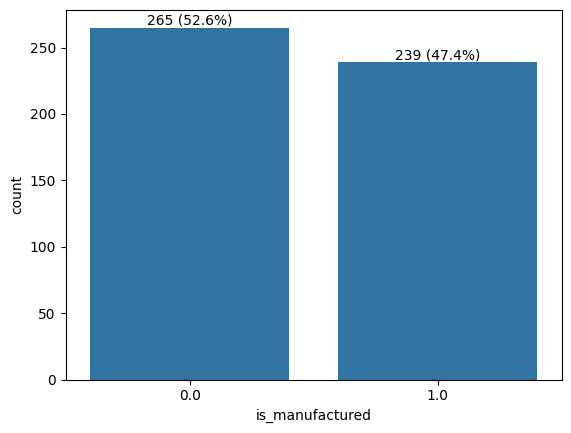

In [21]:
sns.barplot(x=df['is_manufactured'].value_counts().index, y=df['is_manufactured'].value_counts())
total = len(df['is_manufactured'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(f'{int(p.get_height())} ({percentage})', (x, y), ha='center', va='bottom')

In [22]:
# <Student to fill this section>
feature_1_insights = """
The 'is_manufactured' feature is a binary categorical variable that indicates whether a product is manufactured in-house (represented by 1.0) or sourced
externally (represented by 0.0). The distribution of this feature is relatively balanced, with 239 products (47.4%) being manufactured in-house and 265
products (52.6%) being external. This balanced representation suggests that both manufacturing and sourcing strategies play significant roles in the
product catalog and can be further analyzed for potential correlations with other product attributes.
"""

In [23]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `is_sellable`

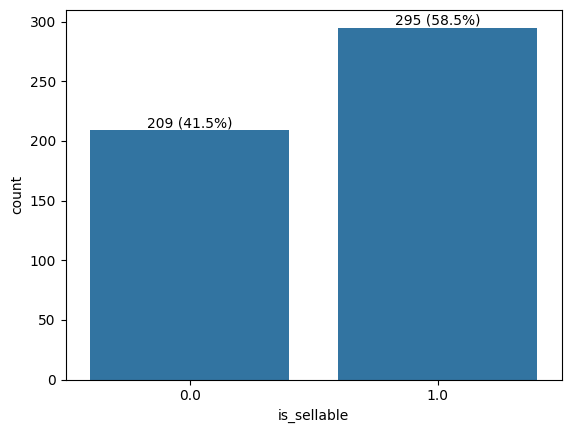

In [24]:
sns.barplot(x=df['is_sellable'].value_counts().index, y=df['is_sellable'].value_counts())
total = len(df['is_sellable'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(f'{int(p.get_height())} ({percentage})', (x, y), ha='center', va='bottom')

In [25]:
df.groupby('is_sellable')['is_manufactured'].value_counts()

is_sellable  is_manufactured
0.0          0.0                182
             1.0                 27
1.0          1.0                212
             0.0                 83
Name: count, dtype: int64

In [26]:
for is_sellable in [0, 1]:
    for is_manufactured in [0, 1]:
        print(f"is_sellable = {is_sellable} & is_manufactured = {is_manufactured}")
        print(list(df[(df['is_sellable'] == is_sellable)
        & (df['is_manufactured'] == is_manufactured)
        & df['name'].notna()].sample(3, random_state=42)['name']))

is_sellable = 0 & is_manufactured = 0
['Lock Washer 10', 'Thin-Jam Lock Nut 12', 'HL Road Rim']
is_sellable = 0 & is_manufactured = 1
['ML Touring Seat Assembly', 'Touring End Caps', 'Road End Caps']
is_sellable = 1 & is_manufactured = 0
['Hitch Rack - 4-Bike', 'Touring Tire', 'Bike Wash - Dissolver']
is_sellable = 1 & is_manufactured = 1
['Touring-2000 Blue, 46', 'Touring Rear Wheel', 'LL Touring Frame - Yellow, 50']


In [27]:
# <Student to fill this section>
feature_2_insights = """
The 'is_sellable' feature is a binary categorical variable indicating whether a product is available for sale (1.0) or not (0.0). Among the 504 unique
products in the dataset, 295 products (approximately 58.5%) are marked as sellable, while 209 products (approximately 41.5%) are not. This distribution
shows that a majority of products are intended for sale, but a significant portion is not. When cross-referencing 'is_manufactured' with 'is_sellable',
the products fall into four distinct business categories. Firstly, Purchased & Not Sold (182 items) - These can be considered raw materials. These include
products like road rim and lock nut. Secondly, we have Manufactured & Sold (212 items) - These might be the core products. The company builds these
in-house, and they are finished goods ready for the retail market. These include products like seat assembly and end caps. Thirdly we have Purchased & Sold
(83 items) - These are resale merchandise. The company buys these from external vendors and sells them directly to the public. These include products like
bike wash and tire. Lastly, we have Manufactured & Not Sold (27 items) - These are internal sub-assemblies. The company builds these in-house, but they are
not offered to the public. These include products like rear wheel and bike frame.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Explore Feature of Interest `safety_stock_level`

<Axes: xlabel='safety_stock_level', ylabel='Count'>

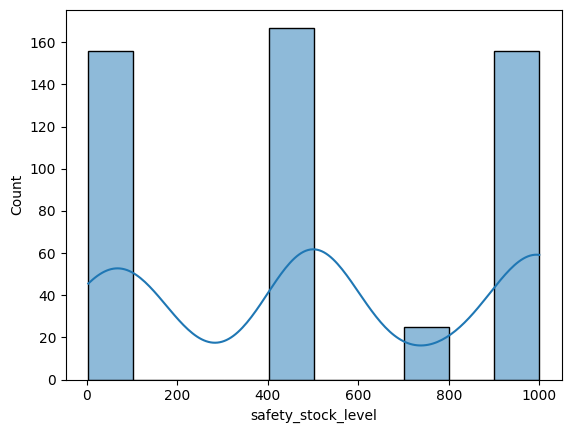

In [29]:
sns.histplot(df['safety_stock_level'], bins='auto', kde=True)

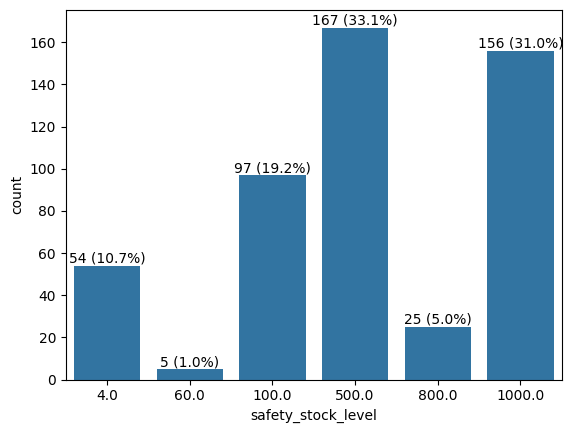

In [30]:
sns.barplot(x=df['safety_stock_level'].value_counts().index, y=df['safety_stock_level'].value_counts())
total = len(df['safety_stock_level'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(f'{int(p.get_height())} ({percentage})', (x, y), ha='center', va='bottom')

<Axes: xlabel='safety_stock_level', ylabel='Count'>

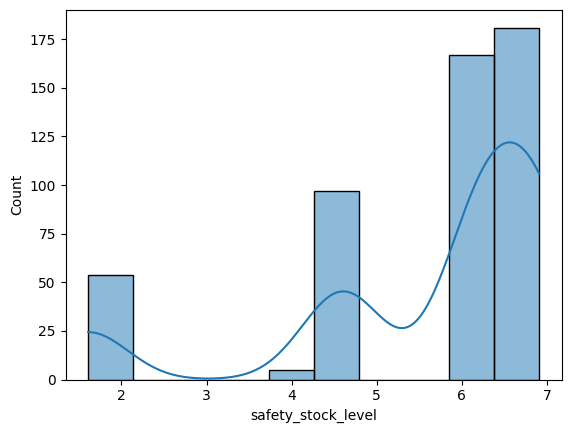

In [31]:
sns.histplot(np.log1p(df['safety_stock_level']), kde=True, bins='auto')

In [32]:
# <Student to fill this section>
feature_3_insights = """
The 'safety_stock_level' feature represents the safety stock quantity for each product. While numerically continuous, this feature exhibits a limited
number of distinct values (6 unique values) ranging from 4 to 1000. Due to this a log transformation might be beneficial for future analysis, to bring all
the values in a comparable scale. The distinct values suggest that safety stock levels might be assigned based on specific product categories or business
rules rather than being purely continuous.
"""

In [33]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### B.5 Explore Feature of Interest `reorder_point`

<Axes: xlabel='reorder_point', ylabel='Count'>

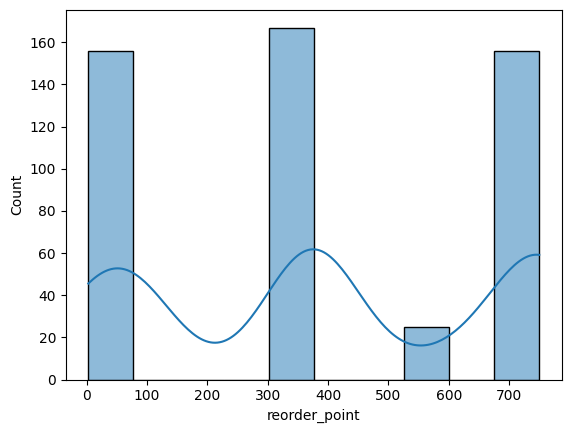

In [34]:
sns.histplot(df['reorder_point'], bins='auto', kde=True)

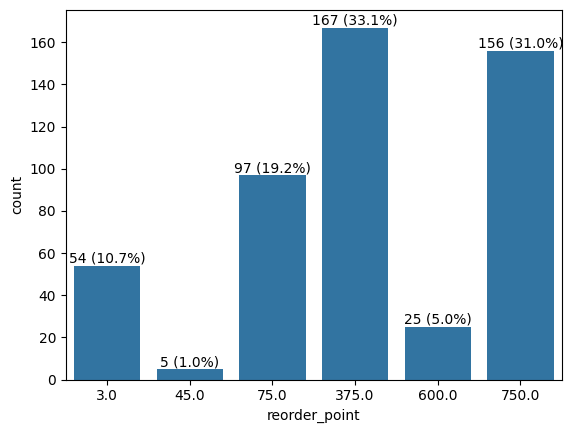

In [35]:
sns.barplot(x=df['reorder_point'].value_counts().index, y=df['reorder_point'].value_counts())
total = len(df['reorder_point'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(f'{int(p.get_height())} ({percentage})', (x, y), ha='center', va='bottom')

<Axes: xlabel='reorder_point', ylabel='Count'>

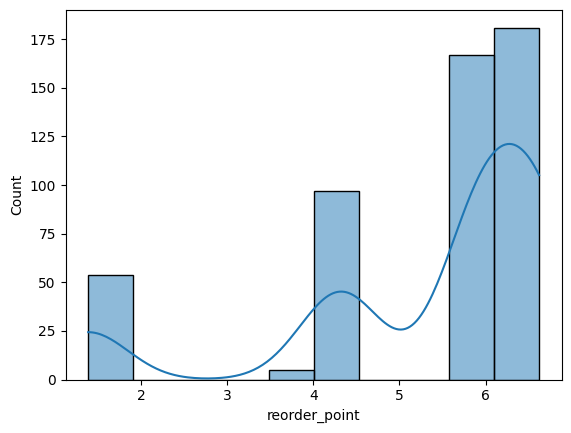

In [36]:

sns.histplot(np.log1p(df['reorder_point']), kde=True, bins='auto')

In [37]:
df.groupby('reorder_point')['safety_stock_level'].value_counts()

,,count
reorder_point,safety_stock_level,
3.0,4.0,54
45.0,60.0,5
75.0,100.0,97
375.0,500.0,167
600.0,800.0,25
750.0,1000.0,156


In [38]:
# <Student to fill this section>
feature_4_insights = """
The 'reorder_point' feature represents the inventory level at which new stock needs to be restocked for a product. Similar to 'safety_stock_level', this
feature is numerically continuous but exhibits a limited number of distinct values (6 unique values), ranging from 3 to 750. Due to this a log
transformation could be beneficial for future analysis. A notable observation is the strong, consistent relationship between 'reorder_point' and
'safety_stock_level'. For every unique 'safety_stock_level', there is a corresponding unique 'reorder_point' value (e.g., a safety stock of 4.0
consistently has a reorder point of 3.0, and 1000.0 has 750.0). This suggests that 'reorder_point' is likely a derived value, calculated based on
'safety_stock_level' through a predefined business rule or formula, reflecting a structured inventory management policy.
"""

In [39]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### B.6 Explore Feature of Interest `days_to_manufacture`

<Axes: xlabel='days_to_manufacture', ylabel='Count'>

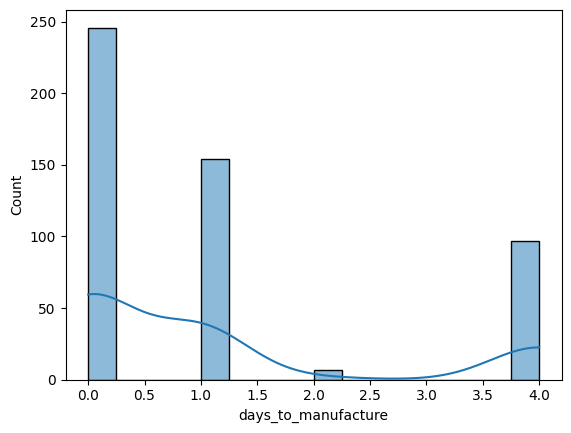

In [40]:
sns.histplot(df['days_to_manufacture'], bins='auto', kde=True)

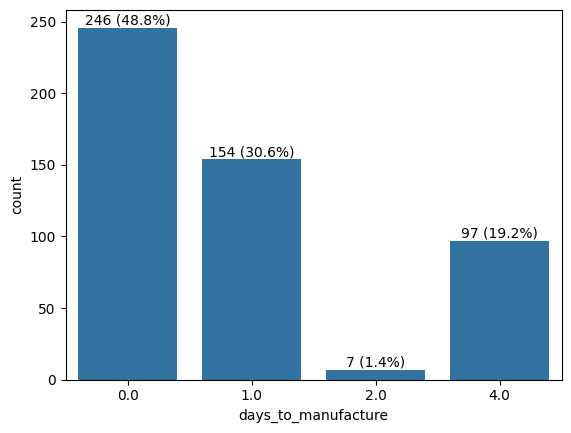

In [41]:
sns.barplot(x=df['days_to_manufacture'].value_counts().index, y=df['days_to_manufacture'].value_counts())
total = len(df['days_to_manufacture'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(f'{int(p.get_height())} ({percentage})', (x, y), ha='center', va='bottom')

In [42]:
df.groupby('is_manufactured')['days_to_manufacture'].value_counts()

is_manufactured  days_to_manufacture
0.0              0.0                    246
                 1.0                     19
1.0              1.0                    135
                 4.0                     97
                 2.0                      7
Name: count, dtype: int64

In [43]:
# <Student to fill this section>
feature_5_insights = """
The 'days_to_manufacture' feature represents the estimated number of days required to produce or assemble a product. This feature is numerical but exhibits
a very limited number of distinct integer values (0, 1, 2, 4). The distribution is heavily imbalanced, with 0 days being the most frequent, followed by 1,
4, and 2 days, respectively, with the lowest being 2, only containing 7 samples. When cross-referenced with the 'is_manufactured' feature - Products not
manufactured, overwhelmingly have 'days_to_manufacture' as 0 (246 products), with a small exception of 19 products taking 1 day. This is logical, as
products not manufactured in-house would not require manufacturing time. Products manufactured in-house show varying 'days_to_manufacture' values: 1 day
(135 products), 4 days (97 products), and 2 days (7 products). This distribution is expected for products that undergo an internal manufacturing process,
reflecting different production complexities or lead times.
"""

In [44]:
# Do not modify this code
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

### B.7 Explore Feature of Interest `product_subcategory_id`

In [46]:
for csv_file in os.listdir(at.folder_path):
    if csv_file.endswith('.csv'):
        try:
            if 'product_subcategory_id' in pd.read_csv(at.folder_path / csv_file).columns:
                print(csv_file)
        except UnicodeDecodeError:
            print(f"Warning: Could not read {csv_file} with default encoding. Skipping or consider specifying encoding.")
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")

product_sub_category.csv
product.csv


In [47]:
df[df['product_subcategory_id'].isna()].groupby('is_manufactured')['is_sellable'].value_counts()

,,count
is_manufactured,is_sellable,
0.0,0.0,182
1.0,0.0,27


In [48]:
bool((df['is_sellable'] == 0).sum() == (df['product_subcategory_id'].isna().sum()))

True

In [49]:
# <Student to fill this section>
feature_6_insights = """
The 'product_subcategory_id' feature serves as a categorical identifier for product subcategories. This feature contains 295 non-null values. Notably, all
209 products that lack a `product_subcategory_id` are precisely those products where `is_sellable` is 0 (i.e., 'Purchased & Not Sold' or 'Manufactured &
Not Sold'). This indicates a systematic pattern where subcategory IDs are exclusively assigned to sellable products. This feature acts as a foreign key,
linking the 'product' dataset to 'product_sub_category.csv', enabling detailed analysis of product subcategories for sellable items.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='feature_6_insights', value=feature_6_insights)

### B.8 Explore Feature of Interest `product_model_id`

In [55]:
for csv_file in os.listdir(at.folder_path):
    if csv_file.endswith('.csv'):
        try:
            if 'product_model_id' in pd.read_csv(at.folder_path / csv_file).columns:
                print(csv_file)
        except UnicodeDecodeError:
            print(f"Warning: Could not read {csv_file} with default encoding. Skipping or consider specifying encoding.")
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")

product.csv


<Axes: xlabel='product_model_id', ylabel='Count'>

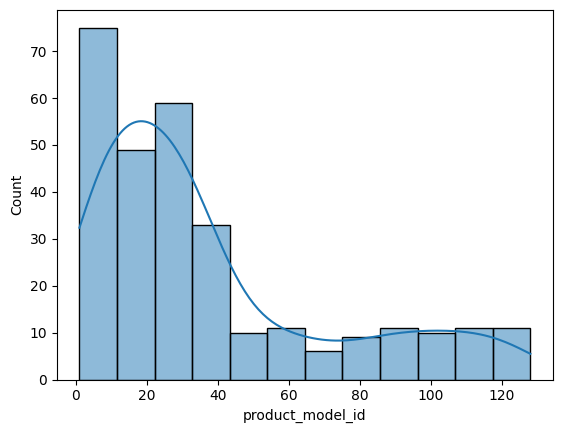

In [56]:
sns.histplot(df['product_model_id'], bins='auto', kde=True)

In [57]:
df[df['product_model_id'].isna()].groupby('is_manufactured')['is_sellable'].value_counts()

,,count
is_manufactured,is_sellable,
0.0,0.0,182
1.0,0.0,27


In [58]:
bool((df['is_sellable'] == 0).sum() == (df['product_model_id'].isna().sum()))

True

In [59]:
# <Student to fill this section>
feature_7_insights = """
The 'product_model_id' represents a 'Base Model' or 'Product Family', with small integer values (1 to 128) suggesting 128 distinct core product designs.
Similar to `product_subcategory_id`, all products with a missing `product_model_id` are precisely those where `is_sellable` is 0 (i.e., non-sellable items
like 'Purchased & Not Sold' or 'Manufactured & Not Sold'). This systematic pattern implies that 'product_model_id' is only assigned to sellable products,
indicating that non-sellable components or raw materials do not have a defined product model in the same way as products offered for sale. Without an
external lookup table, this numerical ID primarily serves to group related sellable products by design or family.
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='feature_7_insights', value=feature_7_insights)

### B.9 Explore Feature of Interest `standard_cost`

<Axes: xlabel='standard_cost', ylabel='Count'>

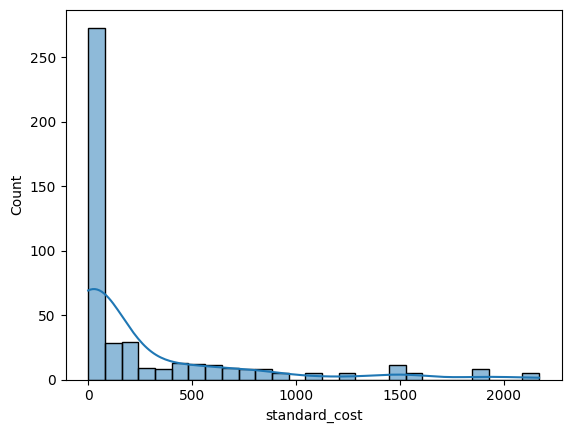

In [61]:
sns.histplot(df['standard_cost'], bins='auto', kde=True)

In [62]:
df['standard_cost'].value_counts().iloc[:30].sort_index()

,count
standard_cost,
0.0000,180
24.7459,4
41.5723,4
98.7700,3
108.9900,3
136.7850,5
144.5938,5
185.8193,4
187.1571,6


<Axes: xlabel='standard_cost', ylabel='Count'>

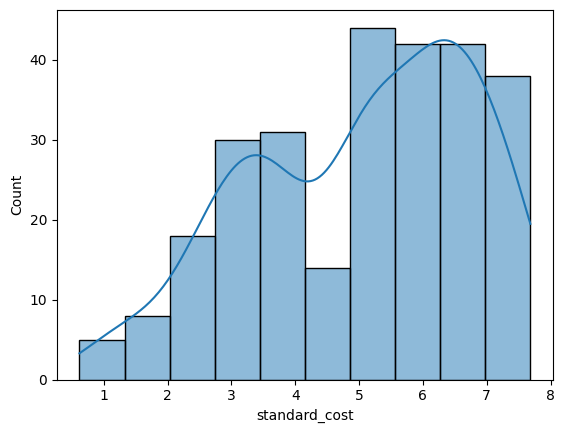

In [63]:
sns.histplot(x=np.log1p(df[df['standard_cost'] > 0]['standard_cost']), bins='auto', kde=True)

In [64]:
df[df['standard_cost'] == 0].groupby('is_manufactured')['is_sellable'].value_counts()

,,count
is_manufactured,is_sellable,
0.0,0.0,164
1.0,0.0,16


In [65]:
df[(df['is_sellable'] == 0) & (df['standard_cost'] > 0)][['name', 'is_manufactured']]

,name,is_manufactured
14,ML Touring Seat Assembly,1.0
52,ML Road Seat Assembly,1.0
99,NaN,1.0
108,ML Mountain Seat Assembly,1.0
175,HL Mountain Seat Assembly,1.0
588,LL Touring Seat Assembly,1.0
597,HL Touring Seat Assembly,1.0
856,LL Mountain Seat Assembly,1.0


In [66]:
df[df['name'].str.contains('Seat Assembly', na=False)][['name', 'is_manufactured']]

,name,is_manufactured
14,ML Touring Seat Assembly,1.0
52,ML Road Seat Assembly,1.0
108,ML Mountain Seat Assembly,1.0
175,HL Mountain Seat Assembly,1.0
588,LL Touring Seat Assembly,1.0
597,HL Touring Seat Assembly,1.0
856,LL Mountain Seat Assembly,1.0


In [67]:
df[df['standard_cost'].isna()].groupby('is_manufactured')['is_sellable'].value_counts()

is_manufactured  is_sellable
0.0              0.0            18
                 1.0            10
1.0              1.0            21
                 0.0             3
Name: count, dtype: int64

In [68]:
df[df['standard_cost'].isna()][['name', 'product_model_id', 'days_to_manufacture', 'reorder_point']]

,name,product_model_id,days_to_manufacture,reorder_point
7,NaN,5.0,2.0,375.0
28,NaN,NaN,0.0,750.0
37,"ML Road Frame-W - Yellow, 44",17.0,1.0,375.0
45,NaN,90.0,0.0,375.0
47,"ML Road Frame - Red, 52",16.0,1.0,375.0
56,Lock Nut 10,NaN,0.0,750.0
59,HL Mountain Tire,87.0,0.0,375.0
74,Fender Set - Mountain,121.0,0.0,3.0
80,"Long-Sleeve Logo Jersey, M",11.0,0.0,3.0
81,NaN,10.0,1.0,375.0


<Axes: ylabel='standard_cost'>

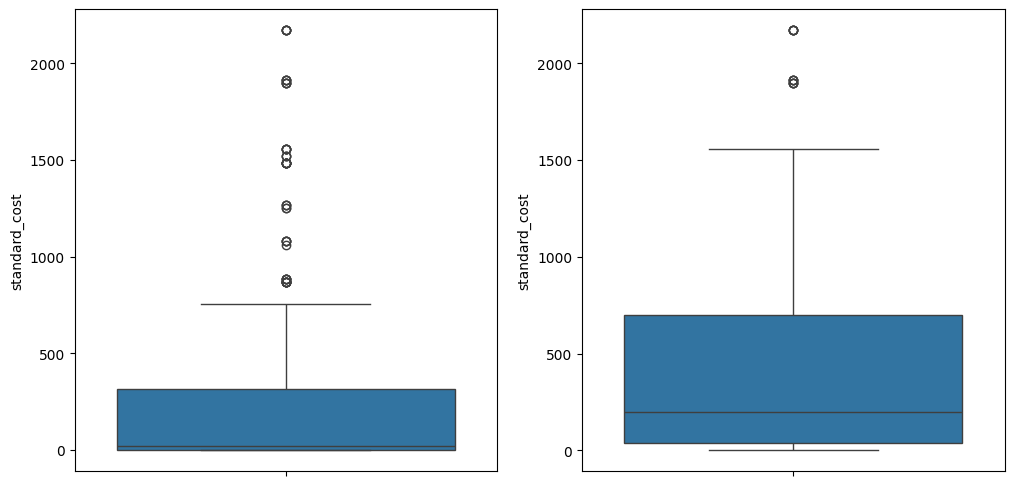

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=df['standard_cost'], ax=axes[0])
sns.boxplot(y=df[df['standard_cost'] > 0]['standard_cost'], ax=axes[1])

In [70]:
feature_8_insights = """
The 'standard_cost' feature represents the cost to produce or acquire a product. A significant portion of products (180 out of 504) have a 'standard_cost'
of 0. Upon cross-referencing with 'is_manufactured' and 'is_sellable', it is observed that all products with a 'standard_cost' of 0 are not sellable.
Specifically, 164 of these products are 'Purchased & Not Sold' (likely raw materials or components) and 16 are 'Manufactured & Not Sold' (likely internal
sub-assemblies). This systematic pattern indicates that a 'standard_cost' of 0 is not a data error, but rather a deliberate accounting or inventory
management practice. It suggests that for non-sellable items, such as raw materials or intermediate components used in the manufacturing process, a direct
individual standard cost is either not tracked separately or is incorporated into the cost structure of the final sellable products they support.
Additionally, products with 'is_sellable' equal to 0 but a non-zero 'standard_cost' are predominantly manufactured assembly-related components, specifically
seat assemblies. Their non-zero cost indicates that these items participate in internal manufacturing and inventory accounting processes, even though they
are not classified as final customer-facing sellable products. In contrast, the missing values observed in related product identification fields (such as
'product_number') do not exhibit a consistent structural or business-related pattern. The missing entries appear across different product categories,
manufacturing statuses, and sellability groups, suggesting that these missing values are likely the result of incomplete data entry, migration issues, or
data collection inconsistencies rather than intentional business logic. The box plot for 'standard_cost' (including zero values) shows a high concentration
at 0, while the box plot excluding zero values shows the distribution of actual costs, highlighting potential outliers and the overall spread of non-zero
standard costs.
"""

In [71]:
# Do not modify this code
print_tile(size="h3", key='feature_8_insights', value=feature_8_insights)

### B.10 Explore Feature of Interest `list_price`

<Axes: xlabel='list_price', ylabel='Count'>

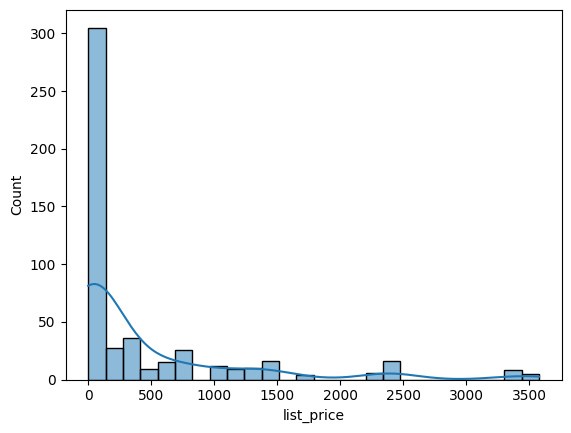

In [72]:
sns.histplot(df['list_price'], bins='auto', kde=True)

In [73]:
df['list_price'].value_counts().iloc[:30].sort_index()

,count
list_price,
0.00,200
8.99,4
34.99,4
53.99,5
59.99,4
249.79,5
264.05,5
333.42,10
337.22,12


<Axes: xlabel='list_price', ylabel='Count'>

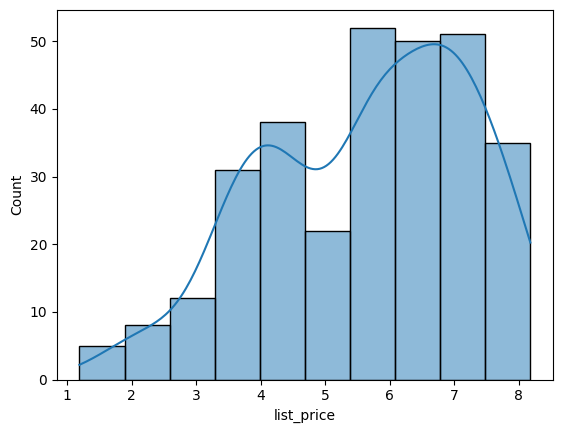

In [74]:
sns.histplot(x=np.log1p(df[df['list_price'] > 0]['list_price']), bins='auto', kde=True)

In [75]:
df[df['list_price'] == 0].groupby('is_manufactured')['is_sellable'].value_counts()

,,count
is_manufactured,is_sellable,
0.0,0.0,182
1.0,0.0,18


In [76]:
df[(df['is_sellable'] == 0) & (df['list_price'] > 0)][['name', 'is_manufactured']]

,name,is_manufactured
14,ML Touring Seat Assembly,1.0
52,ML Road Seat Assembly,1.0
99,NaN,1.0
108,ML Mountain Seat Assembly,1.0
175,HL Mountain Seat Assembly,1.0
323,NaN,1.0
588,LL Touring Seat Assembly,1.0
597,HL Touring Seat Assembly,1.0
856,LL Mountain Seat Assembly,1.0


<Axes: xlabel='list_price', ylabel='standard_cost'>

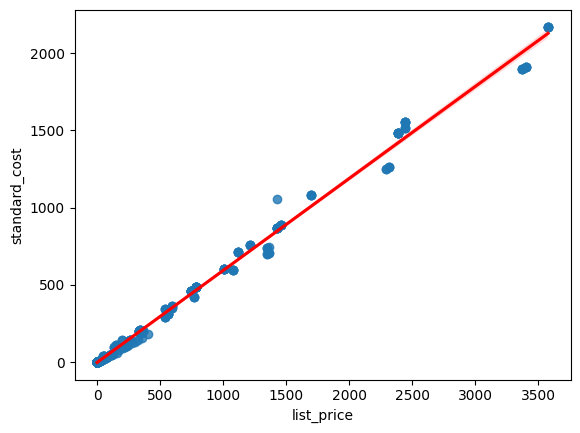

In [77]:
sns.regplot(data=df, x='list_price', y='standard_cost', line_kws={'color': 'red'})

In [78]:
df[df['standard_cost'] == 0]['list_price'].sum()

np.float64(0.0)

In [79]:
len(df['standard_cost'].unique()), len(df['list_price'].unique())

(109, 103)

In [80]:
feature_9_insights = """
The 'list_price' feature represents the price at which a product is sold to customers. Its distribution, as shown by the histogram, indicates a right-
skewed pattern, with many products having lower list prices and fewer products at higher price points. A log transformation of list prices could help
normalize this distribution for better analysis in future. A significant observation is the presence of 200 products with a 'list_price' of 0. Upon cross-
referencing with 'is_manufactured' and 'is_sellable', it's evident that these products align systematically with non-sellable items - 182 products are
'Purchased & Not Sold' and 18 products are 'Manufactured & Not Sold'. This pattern suggests that a 'list_price' of 0 is not an error but a deliberate
reflection of products not intended for direct sale to customers, such as raw materials, components, or internal sub-assemblies. Their value is likely
incorporated into the list price of final, sellable products. Conversely, a small number of products (9 entries) have 'is_sellable' equal to 0 but a
'list_price' greater than 0. These products are primarily 'Seat Assembly' components, which are manufactured in-house. This indicates that while they
might not be classified as sellable as a finished good in the primary product catalog, they might be available as spare parts or replacement items, hence
retaining a non-zero list price. Furthermore, there is a strong linear relationship between 'list_price' and 'standard_cost', as depicted by the scatter
plot and regression line. This linear correlation suggests that if imputation for 'standard_cost' is required, the 'list_price' feature could serve as a
valuable predictor. All products with a 'list_price' of 0 consistently have a 'standard_cost' of 0, indicating a clear, direct relationship for these
specific cases. However, since the number of unique values for 'standard_cost' and 'list_price' are not identical, a direct one-to-one mapping cannot be
assumed for all values, reinforcing the utility of a regression-based imputation approach rather than a simple direct mapping.
"""

In [81]:
# Do not modify this code
print_tile(size="h3", key='feature_9_insights', value=feature_9_insights)

### B.11 Explore Feature of Interest `product_number`

In [82]:
df[df['product_number'].isna()].groupby('is_sellable')['is_manufactured'].value_counts()

is_sellable  is_manufactured
0.0          0.0                15
             1.0                 3
1.0          1.0                19
             0.0                 5
Name: count, dtype: int64

In [83]:
df[(df['product_number'].isna())][['name', 'product_model_id', 'days_to_manufacture', 'reorder_point', 'list_price']].sample(25)

,name,product_model_id,days_to_manufacture,reorder_point,list_price
392,"Mountain-300 Black, 38",21.0,4.0,75.0,1079.990
686,"Road-350-W Yellow, 40",27.0,4.0,75.0,1700.990
124,Lock Ring,NaN,0.0,750.0,0.000
94,NaN,27.0,4.0,75.0,1700.990
127,Front Derailleur Linkage,NaN,0.0,600.0,0.000
95,Lock Nut 14,NaN,0.0,750.0,0.000
331,"Racing Socks, L",24.0,0.0,3.0,8.990
835,Water Bottle - 30 oz.,111.0,0.0,3.0,4.990
690,Decal 2,NaN,0.0,750.0,0.000
135,NaN,6.0,1.0,375.0,1431.500


In [86]:
for csv_file in os.listdir(at.folder_path):
    if csv_file.endswith('.csv'):
        try:
            if 'product_number' in pd.read_csv(at.folder_path / csv_file).columns:
                print(csv_file)
        except UnicodeDecodeError:
            print(f"Warning: Could not read {csv_file} with default encoding. Skipping or consider specifying encoding.")
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")

product.csv


In [87]:
feature_10_insights = """
The 'product_number' feature, intended to uniquely identify products, presents a challenge due to a significant number of missing values (42 out of 504
products). Upon investigation, the distribution of these missing values does not exhibit a systematic pattern related to 'is_manufactured' or 'is_sellable'
status. This random distribution suggests that the missing 'product_number' entries are likely due to data incompleteness, legacy data issues, or
inconsistencies in data entry rather than a specific business rule or product characteristic. The 'product_number' itself consists of alphanumeric values,
which could indicate its use as warehouse code or an internal identifier. However, in the context of this dataset, it does not appear to act as a foreign
key linking to any other tables, limiting its utility for direct relational analysis beyond unique product identification.
"""

In [88]:
# Do not modify this code
print_tile(size="h3", key='feature_10_insights', value=feature_10_insights)

### B.12 Explore Feature of Interest `size` and `size_unit_measure_code`

<Axes: xlabel='count', ylabel='size'>

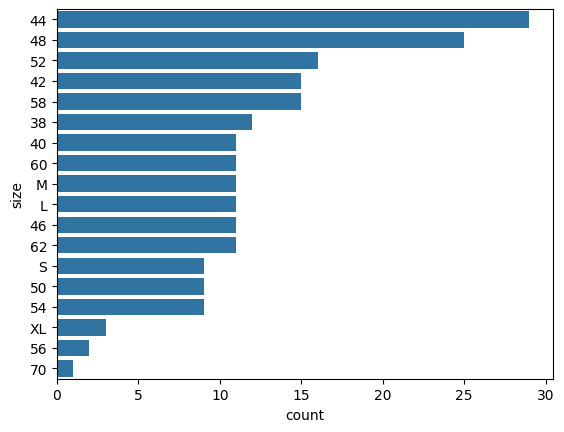

In [89]:
sns.barplot(y=df['size'].value_counts().index, x=df['size'].value_counts())

In [90]:
df[(df['name'].notna()) & (df['size'].notna())]['name'].sample(25)

,name
324,"ML Mountain Frame-W - Silver, 38"
880,"LL Mountain Frame - Black, 44"
226,"Road-150 Red, 44"
825,"LL Mountain Frame - Silver, 40"
41,"Road-550-W Yellow, 42"
434,"HL Road Frame - Red, 52"
792,"Mountain Bike Socks, L"
377,"Mountain-500 Silver, 52"
869,"Short-Sleeve Classic Jersey, M"
876,"Mountain-100 Silver, 38"


In [91]:
df[(df['name'].notna()) & (df['size'].isna())]['name'].sample(25)

,name
709,LL Touring Seat/Saddle
597,HL Touring Seat Assembly
98,Road Tire Tube
134,Thin-Jam Lock Nut 7
244,Internal Lock Washer 8
61,HL Mountain Rear Wheel
112,Flat Washer 4
867,Thin-Jam Hex Nut 11
74,Fender Set - Mountain
100,Lock Nut 18


In [92]:
df[df['size'].isna()].groupby('is_manufactured')['is_sellable'].value_counts()

is_manufactured  is_sellable
0.0              0.0            182
                 1.0             48
1.0              1.0             36
                 0.0             27
Name: count, dtype: int64

In [93]:
df.groupby('is_manufactured')['is_sellable'].value_counts()

is_manufactured  is_sellable
0.0              0.0            182
                 1.0             83
1.0              1.0            212
                 0.0             27
Name: count, dtype: int64

In [94]:
df[(df['size'].isna()) & (df['is_sellable'] == 1)].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,84,84,71cee1fa-a7d3-423a-8bf8-d586f864dc30,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,84.0,NaN,NaN,NaN,0.428571,0.497844,0.0,0.0,0.0,1.0,1.0
is_sellable,84.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
safety_stock_level,84.0,NaN,NaN,NaN,387.809524,208.754798,4.0,500.0,500.0,500.0,500.0
reorder_point,84.0,NaN,NaN,NaN,290.857143,156.566099,3.0,375.0,375.0,375.0,375.0
days_to_manufacture,84.0,NaN,NaN,NaN,0.654762,0.478301,0.0,0.0,1.0,1.0,1.0
product_subcategory_id,84,23,f9a7e077-33a4-4ef3-b979-beaf4bf163de,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,84.0,NaN,NaN,NaN,82.714286,28.651446,2.0,58.75,85.5,106.5,128.0
name,71,71,Touring Tire,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,80,80,TI-T723,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
temp = df[(df['size'].isin(['XL', 'M', 'L', 'S'])) & (df['name'].notna())]['name']
print(len(temp))
display(temp)

28


,name
17,"Short-Sleeve Classic Jersey, XL"
43,"Men's Sports Shorts, L"
80,"Long-Sleeve Logo Jersey, M"
104,"Full-Finger Gloves, L"
110,"Classic Vest, S"
137,"Half-Finger Gloves, L"
168,"Mountain Bike Socks, M"
225,"Men's Sports Shorts, M"
263,"Long-Sleeve Logo Jersey, S"
281,"Short-Sleeve Classic Jersey, S"


In [96]:
clothing_keywords = ['jersey', 'shorts', 'socks', 'gloves', 'vest', 'tights']
clothing_df = df[df['name'].str.contains('|'.join(clothing_keywords), case=False, na=False)]
print(len(clothing_df))

28


In [97]:
temp = df[(df['size_unit_measure_code'].isna()) & (df['size'].notna()) & (df['name'].notna())][['name', 'size']]
print(len(temp))
display(temp)

29


,name,size
17,"Short-Sleeve Classic Jersey, XL",XL
43,"Men's Sports Shorts, L",L
80,"Long-Sleeve Logo Jersey, M",M
104,"Full-Finger Gloves, L",L
110,"Classic Vest, S",S
137,"Half-Finger Gloves, L",L
168,"Mountain Bike Socks, M",M
225,"Men's Sports Shorts, M",M
263,"Long-Sleeve Logo Jersey, S",S
281,"Short-Sleeve Classic Jersey, S",S


In [100]:
for csv_file in os.listdir(at.folder_path):
    if csv_file.endswith('.csv'):
        try:
            if 'size_unit_measure_code' in pd.read_csv(at.folder_path / csv_file).columns:
                print(csv_file)
        except UnicodeDecodeError:
            print(f"Warning: Could not read {csv_file} with default encoding. Skipping or consider specifying encoding.")
        except Exception as e:
            print(f"Error reading {csv_file}: {e}")

product.csv


In [101]:
os.listdir(at.folder_path)

['customer.csv',
 'person.csv',
 'product_category.csv',
 'product_cost_history.csv',
 'product_list_price_history.csv',
 'product_sub_category.csv',
 'product.csv',
 'sales_order_detail.csv',
 'sales_order_header.csv',
 'sales_territory.csv',
 'special_offer_product.csv',
 'special_offer.csv',
 'store.csv',
 'unit_measure.csv',
 'scaler.pkl',
 'X_train.csv']

In [102]:
unit_measure_df = pd.read_csv(at.folder_path / 'unit_measure.csv')
unique_codes = pd.Series(df['size_unit_measure_code'].dropna().unique())
unit_measure_df[
    unit_measure_df['unit_measure_code'].isin(unique_codes.sample(n=min(5, len(unique_codes)), replace=False))]

,unit_measure_code,name
8,e2e52698-ce31-4fb2-866f-bcffbdfd3147,Centimeter


In [103]:
feature_11_insights = """
The 'size' feature, despite being stored as an object type, contains a mix of numerical and categorical values, indicating varying sizing conventions across
products. Non-numeric size values such as 'XL', 'M', 'L' and 'S' are associated with clothing products. A significant portion of products have missing 'size'
values (293 out of 504 products). Upon inspection, these products are primarily accessories, components, or non-essential items like 'Lock Nut', 'Washer',
'Decal', 'Saddle', 'Fender Set', 'Steerer', 'Tension Pulley', 'Hitch Rack', and 'Bike Wash'. Furthermore, most of these products are often associated with
'is_sellable == 0' (non-sellable) or are less critical components. This suggests that sizing information is either irrelevant or not tracked for these types
of products, which are typically not the primary revenue-generating items. Conversely, essential products such as bicycle frames ('Mountain Frame',
'Road Frame'), complete bikes ('Mountain-100', 'Road-250', 'Touring-3000'), and other key components often have well-defined numeric values. This indicates
that 'size' is a critical attribute for primary products, impacting their fit, compatibility, and market segmentation. The 'size_unit_measure_code' feature
complements 'size' by providing the unit of measurement. When present, this code consistently maps to 'Centimeter', indicating that numerical sizes are
recorded in centimeters. Notably, 'size_unit_measure_code' is missing (NaN) for all clothing products (that have categorical sizes like 'XL', 'M', 'L', and
'S'), suggesting that these non-numeric size values do not have an explicit unit within the dataset. An interesting exception is 'Hydration Pack - 70 oz.',
which has a numerical size of '70' but is missing a 'size_unit_measure_code'.
"""

In [104]:
# Do not modify this code
print_tile(size="h3", key='feature_11_insights', value=feature_11_insights)

### B.13 Explore Feature of Interest `weight` and `weight_unit_measure_code`

In [105]:
df[df['weight'].isna()].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,299,299,0ebd0784-173e-45b5-b534-a953030f49f0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,299.0,NaN,NaN,NaN,0.16388,0.370787,0.0,0.0,0.0,0.0,1.0
is_sellable,299.0,NaN,NaN,NaN,0.324415,0.468941,0.0,0.0,0.0,1.0,1.0
safety_stock_level,299.0,NaN,NaN,NaN,681.993311,388.464176,4.0,500.0,1000.0,1000.0,1000.0
reorder_point,299.0,NaN,NaN,NaN,511.494983,291.348132,3.0,375.0,750.0,750.0,750.0
days_to_manufacture,299.0,NaN,NaN,NaN,0.200669,0.401172,0.0,0.0,0.0,0.0,1.0
product_subcategory_id,97,27,4f0705e2-0929-407d-aebe-7d39f2cd831c,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,97.0,NaN,NaN,NaN,59.515464,40.044536,1.0,24.0,55.0,93.0,125.0
name,243,243,External Lock Washer 4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,277,277,MS-2341,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
df[(df['weight'].isna()) & (df['size'].notna())]['size'].value_counts()

,count
size,
M,11
L,11
S,9
XL,3
70,1


In [107]:
df[(df['size'].isna()) & (df['weight'].notna())].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,29,29,c51bb610-3391-42d9-921a-8ac5ea5fe70a,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,29.0,NaN,NaN,NaN,0.482759,0.508548,0.0,0.0,0.0,1.0,1.0
is_sellable,29.0,NaN,NaN,NaN,0.758621,0.435494,0.0,1.0,1.0,1.0,1.0
safety_stock_level,29.0,NaN,NaN,NaN,572.413793,130.648251,500.0,500.0,500.0,500.0,800.0
reorder_point,29.0,NaN,NaN,NaN,429.310345,97.986188,375.0,375.0,375.0,375.0,600.0
days_to_manufacture,29.0,NaN,NaN,NaN,0.758621,0.435494,0.0,1.0,1.0,1.0,1.0
product_subcategory_id,22,6,94ce21f6-249d-468d-a859-a7cac5f87bb0,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,22.0,NaN,NaN,NaN,85.227273,24.844146,49.0,65.0,86.5,100.75,128.0
name,22,22,LL Road Pedal,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,26,26,PD-R347,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [108]:
unique_codes = pd.Series(df['weight_unit_measure_code'].dropna().unique())
unit_measure_df[
    unit_measure_df['unit_measure_code'].isin(unique_codes.sample(n=min(5, len(unique_codes)), replace=False))]

,unit_measure_code,name
17,8c4f020f-f9c1-492b-8395-1372b7bda7a7,Gram
25,c4797df8-be0b-4d3a-a6c4-0f1765f0a822,US pound


In [109]:
feature_12_insights = """
The 'weight' feature represents the mass of a product, while 'weight_unit_measure_code' indicates the unit of measurement used (either 'Gram' or 'US
pound'). A significant portion of the products in the dataset have missing 'weight' values. Upon inspection, it's observed that the products with existing
'size' information, particularly categorical clothing sizes like 'M', 'L', 'S', and 'XL'. All the products with missing 'weight' values also don't have a
'size' value (expect clothing products), but the opposite is not true. There are products without any 'size' value but have a missing 'weight' value. This
suggests that for apparel and potentially some other non-hardware items, weight might not be a tracked attribute, or it's considered less relevant.
Conversely, for non-clothing products, the pattern of missing 'weight' data appears random, with some products having values and others not, suggesting a
data entry or data collection inconsistency rather than a systematic business rule. The presence of two distinct weight units ('Gram' and 'US pound')
indicates a need for unit standardization if weight is to be used in quantitative analysis or comparisons, to ensure consistency and avoid
misinterpretations of product mass.
"""

In [110]:
# Do not modify this code
print_tile(size="h3", key='feature_12_insights', value=feature_12_insights)

### B.14 Explore Feature of Interest `product_line`

In [111]:
df['product_line'].value_counts()

,count
product_line,
R,100
M,91
T,52
S,35


In [112]:
df[df['product_line'].isna()].groupby('is_manufactured')['is_sellable'].value_counts()

is_manufactured  is_sellable
0.0              0.0            182
                 1.0              3
1.0              0.0             27
                 1.0             14
Name: count, dtype: int64

In [113]:
display(df[(df['product_line'].isna()) & (df['is_sellable'] == 1) & (df['is_manufactured'] == 0)]['name'])
display(df[(df['product_line'].isna()) & (df['is_sellable'] == 1) & (df['is_manufactured'] == 1)]['name'])

,name
365,Front Brakes
636,Rear Brakes
764,NaN


,name
24,HL Fork
153,LL Headset
162,ML Crankset
212,NaN
338,LL Crankset
416,NaN
446,Front Derailleur
498,HL Crankset
501,ML Headset
561,NaN


In [114]:
for product_line in ['M', 'R', 'T', 'S']:
    print(product_line)
    print(list(df[(df['product_line'] == product_line) & (df['name'].notna())]['name'].sample(5, random_state=42)))

M
['ML Mountain Seat/Saddle', 'Mountain-500 Black, 40', 'ML Mountain Frame-W - Silver, 38', 'HL Mountain Front Wheel', 'Fender Set - Mountain']
R
['HL Road Frame - Black, 48', 'Road-550-W Yellow, 44', 'Road-250 Red, 52', 'LL Road Pedal', 'ML Road Frame - Red, 52']
T
['Touring-2000 Blue, 46', 'HL Touring Frame - Blue, 60', 'LL Touring Frame - Blue, 54', 'Touring-1000 Blue, 60', 'Touring-Panniers, Large']
S
['Water Bottle - 30 oz.', 'Half-Finger Gloves, M', 'Minipump', 'Classic Vest, M', 'Hitch Rack - 4-Bike']


In [115]:
df[df['product_line'].isna()].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,226,226,776904bb-c44c-46c4-9f48-84aa4f194272,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,226.0,NaN,NaN,NaN,0.181416,0.386218,0.0,0.0,0.0,0.0,1.0
is_sellable,226.0,NaN,NaN,NaN,0.075221,0.264333,0.0,0.0,0.0,0.0,1.0
safety_stock_level,226.0,NaN,NaN,NaN,868.584071,226.224538,60.0,800.0,1000.0,1000.0,1000.0
reorder_point,226.0,NaN,NaN,NaN,651.438053,169.668404,45.0,600.0,750.0,750.0,750.0
days_to_manufacture,226.0,NaN,NaN,NaN,0.19469,0.396841,0.0,0.0,0.0,0.0,1.0
product_subcategory_id,17,7,d1d7c22b-3508-4c1c-ae1a-1002f0bddc10,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,17.0,NaN,NaN,NaN,96.529412,19.774092,59.0,96.0,100.0,104.0,128.0
name,178,178,External Lock Washer 4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,208,208,LE-1200,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
feature_13_insights = """
The 'product_line' feature categorizes products into four distinct lines: 'M' (Mountain bikes and accessories), 'R' (Road bikes and accessories), 'T'
(Touring bikes and accessories), and 'S' (Sport bikes and general accessories). This categorical feature helps in understanding the primary segmentation of
the product catalog. A significant observation relates to products with missing 'product_line' values (NaN). Out of 226 such products, the vast majority
are not sellable (182 'Purchased & Not Sold' and 27 'Manufactured & Not Sold'). A smaller number of non-sellable products (3 'Purchased & Sold' and 14
'Manufactured & Sold') also have missing 'product_line'. This indicates that 'product_line' is primarily assigned to products that are part of the core,
sellable product offerings, especially finished goods or key components directly associated with a bike type. Crucially, it is observed that all products
with an unassigned 'product_line' also have unassigned 'size' values (NaN in both 'size' and 'size_unit_measure_code'). This strong correlation suggests
that products without a defined product line are often generic components, raw materials, or accessories for which specific sizing is not relevant or
tracked.
"""

In [117]:
# Do not modify this code
print_tile(size="h3", key='feature_13_insights', value=feature_13_insights)

### B.14 Explore Feature of Interest `class`

In [118]:
df['class'].value_counts()

,count
class,
L,97
H,82
M,68


In [119]:
for c in ['L', 'H', 'M']:
    print(c)
    print(list(df[(df['class'] == c) & (df['name'].notna())]['name'].sample(5, random_state=42)))

L
['LL Road Frame - Red, 60', 'LL Touring Frame - Yellow, 54', 'LL Crankarm', 'Mountain-500 Black, 40', 'Road-650 Red, 60']
H
['HL Mountain Frame - Black, 42', 'HL Headset', 'HL Mountain Seat/Saddle', 'Mountain-100 Black, 48', 'HL Mountain Tire']
M
['Road-550-W Yellow, 44', 'ML Road Frame - Red, 52', 'Mountain-400-W Silver, 40', 'ML Crankset', 'Touring-2000 Blue, 50']


In [120]:
df[df['class'].isna()].groupby('is_manufactured')['is_sellable'].value_counts()

is_manufactured  is_sellable
0.0              0.0            171
                 1.0             62
1.0              0.0             20
                 1.0              4
Name: count, dtype: int64

In [121]:
df[df['class'].isna()].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,257,257,0ebd0784-173e-45b5-b534-a953030f49f0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,257.0,NaN,NaN,NaN,0.093385,0.291539,0.0,0.0,0.0,0.0,1.0
is_sellable,257.0,NaN,NaN,NaN,0.256809,0.437726,0.0,0.0,0.0,1.0,1.0
safety_stock_level,257.0,NaN,NaN,NaN,709.789883,411.323287,4.0,500.0,1000.0,1000.0,1000.0
reorder_point,257.0,NaN,NaN,NaN,532.342412,308.492465,3.0,375.0,750.0,750.0,750.0
days_to_manufacture,257.0,NaN,NaN,NaN,0.108949,0.312184,0.0,0.0,0.0,0.0,1.0
product_subcategory_id,66,25,3efbcaad-1b67-4391-bdcd-505d47385bb2,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,66.0,NaN,NaN,NaN,54.454545,46.014105,1.0,12.25,37.0,107.75,128.0
name,210,210,External Lock Washer 4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,236,236,LE-1200,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
temp = df[(df['class'].isna()) & ((df['size'].notna()) | (df['weight'].notna()))]
display(temp['size'].value_counts())
display(temp['weight'].value_counts())

,count
size,
M,11
L,11
S,9
XL,3
70,1


,count
weight,
317.0,2
400.0,2
88.0,1
460.0,1
215.0,1


In [123]:
temp[temp['size'] == '70']['name']

,name
795,Hydration Pack - 70 oz.


In [124]:
temp[temp['weight'].notna()]['name']

,name
365,Front Brakes
424,HL Mountain Rim
446,Front Derailleur
636,Rear Brakes
638,Touring Rim
768,Rear Derailleur
811,HL Road Rim


In [125]:
feature_14_insights = """
The 'class' feature categorizes products into three distinct classes: 'L', 'H', and 'M', which likely represent different quality tiers or product ranges
(e.g., Low, High, and Medium). This categorical feature further segments the product catalog. There are 257 products with missing 'class' values. Of these,
171 are 'Purchased & Not Sold', 62 are 'Purchased & Sold', 20 are 'Manufactured & Not Sold', and 4 are 'Manufactured & Sold'. This distribution suggests
that while 'class' is primarily assigned to sellable products, a substantial number of sellable products (62 + 4 = 66) also lack a defined class. Upon
closer inspection, products with missing 'class' values but with a defined 'size' are predominantly clothing items (except one exception on hydration pack
- 'Hydration Pack - 70 oz.'), where size is a relevant attribute but 'class' might not be explicitly assigned in the same way as for bicycle components.
Similarly, products with missing 'class' but with a defined 'weight' are typically components like brakes, rims, and derailleurs. This indicates that
'class' is not consistently assigned across all types of products, and its absence is not always indicative of non-sellable or non-essential items. This
suggests that the absence of 'class' could be due to a combination of factors, including the type of product (e.g., accessories vs. main components) and
potential data entry inconsistencies.
"""

In [126]:
# Do not modify this code
print_tile(size="h3", key='feature_14_insights', value=feature_14_insights)

### B.15 Explore Feature of Interest `style`

In [127]:
df['style'].value_counts()

,count
style,
U,176
W,28
M,7


In [128]:
for style in ['U', 'W', 'M']:
    print(style)
    print(list(df[(df['style'] == style) & (df['name'].notna())]['name'].sample(5, random_state=42)))

U
['Touring-3000 Blue, 50', 'HL Touring Frame - Blue, 46', 'HL Touring Frame - Yellow, 46', 'HL Road Frame - Red, 62', 'Mountain-300 Black, 44']
W
['Road-550-W Yellow, 44', 'Road-550-W Yellow, 48', 'Road-350-W Yellow, 40', 'Road-550-W Yellow, 38', "Women's Tights, S"]
M
["Men's Sports Shorts, L", "Men's Sports Shorts, M", "Men's Bib-Shorts, M", "Men's Sports Shorts, S", "Men's Sports Shorts, XL"]


In [129]:
df[df['style'].isna()].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,293,293,0ebd0784-173e-45b5-b534-a953030f49f0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,293.0,NaN,NaN,NaN,0.215017,0.411537,0.0,0.0,0.0,0.0,1.0
is_sellable,293.0,NaN,NaN,NaN,0.286689,0.452989,0.0,0.0,0.0,1.0,1.0
safety_stock_level,293.0,NaN,NaN,NaN,752.136519,311.126249,4.0,500.0,1000.0,1000.0,1000.0
reorder_point,293.0,NaN,NaN,NaN,564.102389,233.344687,3.0,375.0,750.0,750.0,750.0
days_to_manufacture,293.0,NaN,NaN,NaN,0.279863,0.4497,0.0,0.0,0.0,1.0,1.0
product_subcategory_id,84,23,f9a7e077-33a4-4ef3-b979-beaf4bf163de,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,84.0,NaN,NaN,NaN,83.964286,27.348464,33.0,59.75,86.5,107.25,128.0
name,236,236,External Lock Washer 4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,271,271,MS-2341,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
df[(df['style'].isna()) & (df['size'].notna())]['name']

,name
795,Hydration Pack - 70 oz.


In [131]:
df[df['name'] == 'Hydration Pack - 70 oz.'].T

,795
product_id,4660f34e-9756-478f-a608-75985d50bb59
is_manufactured,0.0
is_sellable,1.0
safety_stock_level,4.0
reorder_point,3.0
days_to_manufacture,0.0
product_subcategory_id,fd2406ff-6629-42d0-8287-8204b851b2a2
product_model_id,107.0
name,Hydration Pack - 70 oz.
product_number,HY-1023-70


In [132]:
feature_15_insights = """
The 'style' feature categorizes products into three distinct styles: 'U' (Universal or Unisex), 'W' (Women's specific), and 'M' (Men's specific). This
categorical feature provides insight into the target demographic or design orientation of a product. A significant number of products (293 out of 504)
have missing 'style' values. Upon examining these products, it's evident that the 'style' feature is not assigned to items where gender-specific design or
universal applicability is not relevant. All these products have not assigned any 'size' value, with the notable exception of 'Hydration Pack - 70 oz.',
which has a defined 'size' but no 'style'. This confirms that 'style' is primarily relevant for complete products or apparel where gendered design or fit
is a consideration, and its absence is indicative of products falling outside these categories rather than being an issue of data incompleteness.
"""

In [133]:
# Do not modify this code
print_tile(size="h3", key='feature_15_insights', value=feature_15_insights)

### B.15 Explore Feature of Interest `sell_start_date` and `sell_end_date`

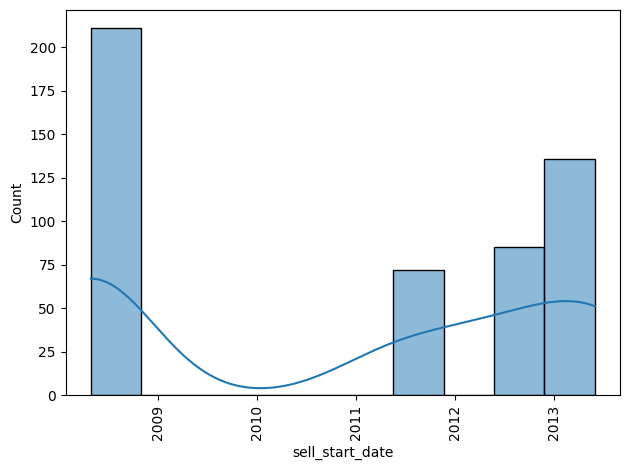

In [134]:
df['sell_start_date'] = pd.to_datetime(df['sell_start_date'])
sns.histplot(df['sell_start_date'], bins='auto', kde=True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

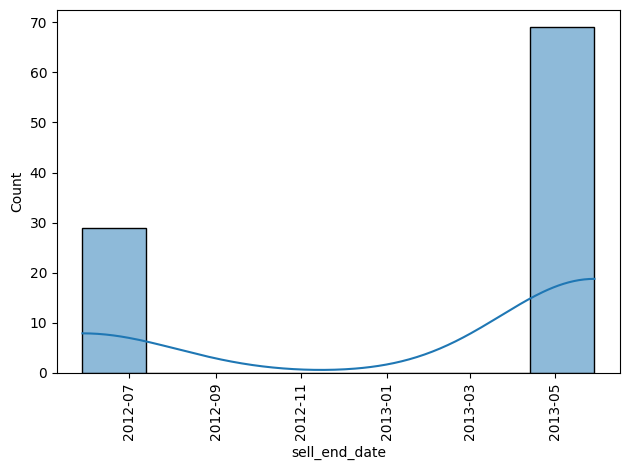

In [135]:
df['sell_end_date'] = pd.to_datetime(df['sell_end_date'])
sns.histplot(df['sell_end_date'], bins='auto', kde=True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [136]:
feature_16_insights = """
The 'sell_start_date' and 'sell_end_date' features define the active sales period for each product. The 'sell_start_date' shows that the majority of
products began selling in 2008. This indicates a continuous product lifecycle management across these years. The 'sell_end_date' is available for only 98
products, with most of these products ending their sales period in 2013, and few products ending in 2012. The remaining 406 products have no 'sell_end_date',
suggesting they are still actively sold or their sales end date was not recorded. In contrast, the 'discontinued_date' column is entirely null. This implies
a clear distinction between 'sell_end_date' and 'discontinued_date'. 'sell_end_date' likely marks the point at which a product is no longer actively
marketed or sold through regular channels, possibly indicating its phasing out or replacement by newer models. 'discontinued_date', if it were populated,
would typically signify the complete cessation of a product's existence, including manufacturing, support, and availability of spare parts.
"""

In [137]:
# Do not modify this code
print_tile(size="h3", key='feature_16_insights', value=feature_16_insights)

### B.16 Explore Feature of Interest `color`

<Axes: xlabel='count', ylabel='color'>

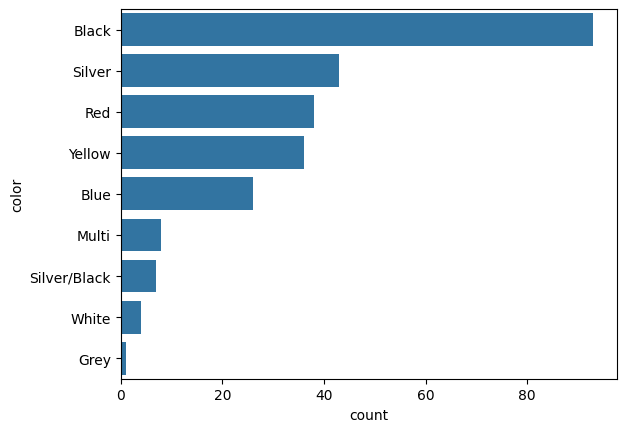

In [138]:
sns.barplot(y=df['color'].value_counts().index, x=df['color'].value_counts())

In [139]:
df[df['color'].isna()].describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
product_id,248,248,776904bb-c44c-46c4-9f48-84aa4f194272,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,248.0,NaN,NaN,NaN,0.177419,0.0,0.0,0.0,0.0,1.0,0.382796
is_sellable,248.0,NaN,NaN,NaN,0.201613,0.0,0.0,0.0,0.0,1.0,0.402016
safety_stock_level,248.0,NaN,NaN,NaN,797.403226,4.0,500.0,1000.0,1000.0,1000.0,302.131106
reorder_point,248.0,NaN,NaN,NaN,598.052419,3.0,375.0,750.0,750.0,750.0,226.598329
days_to_manufacture,248.0,NaN,NaN,NaN,0.21371,0.0,0.0,0.0,0.0,1.0,0.410753
product_subcategory_id,50,14,4f0705e2-0929-407d-aebe-7d39f2cd831c,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,50.0,NaN,NaN,NaN,87.94,47.0,66.25,89.5,108.75,122.0,22.653026
name,199,199,External Lock Washer 4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,231,231,LE-1200,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [140]:
df[(df['size'].isna()) & (df['color'].notna())].describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
product_id,45,45,dd097211-10a3-46a5-ab49-cee940f681b3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_manufactured,45.0,NaN,NaN,NaN,0.422222,0.0,0.0,0.0,1.0,1.0,0.499495
is_sellable,45.0,NaN,NaN,NaN,0.755556,0.0,1.0,1.0,1.0,1.0,0.434613
safety_stock_level,45.0,NaN,NaN,NaN,502.666667,4.0,500.0,500.0,500.0,1000.0,234.024086
reorder_point,45.0,NaN,NaN,NaN,377.0,3.0,375.0,375.0,375.0,750.0,175.518064
days_to_manufacture,45.0,NaN,NaN,NaN,0.644444,0.0,0.0,1.0,1.0,1.0,0.48409
product_subcategory_id,34,9,f9a7e077-33a4-4ef3-b979-beaf4bf163de,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_model_id,34.0,NaN,NaN,NaN,75.029412,2.0,46.75,68.5,101.75,128.0,34.648438
name,37,37,LL Crankarm,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_number,40,40,CA-5965,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
df[(df['color'].isna()) & (df['name'].notna())]['name'].sample(25, random_state=42)

,name
329,Cable Lock
60,Flat Washer 6
473,External Lock Washer 8
759,Lock Washer 5
299,HL Touring Seat/Saddle
710,HL Road Handlebars
250,Lock Nut 9
247,Lock Nut 20
517,Bearing Ball
750,ML Road Rim


In [142]:
feature_17_insights = """
The 'color' feature categorizes products into nine distinct colors, with 'Black' being the most prevalent. A significant portion of the dataset, 248 out of
504 products, have missing 'color' values. These products are predominantly accessory items, such as 'Lock Nut', 'Washer', 'Cable Lock', 'Bearing Ball',
and 'Seat Post', for which color might not be a critical attribute or is not explicitly tracked. All products with missing 'color' also have missing 'size'
and 'style'. But, some products without a defined 'size' or 'style' do have a 'color' assigned. This indicates that while 'color' is a crucial descriptive
attribute for many products, its absence is often systematic, reflecting the nature of certain components or non-consumer-facing items.
"""

In [143]:
# Do not modify this code
print_tile(size="h3", key='feature_17_insights', value=feature_17_insights)